In [5]:
# Project: Insurance Customer Response Prediction

# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models & Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report
)


In [6]:
# 1. Load Dataset

df = pd.read_csv("data.csv")
print("✅ Data Loaded Successfully!")
print(df.head())

✅ Data Loaded Successfully!
   id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0   1    Male   44                1         28.0                   0   
1   2    Male   76                1          3.0                   0   
2   3    Male   47                1         28.0                   0   
3   4    Male   21                1         11.0                   1   
4   5  Female   29                1         41.0                   1   

  Vehicle_Age Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  \
0   > 2 Years            Yes         40454.0                  26.0      217   
1    1-2 Year             No         33536.0                  26.0      183   
2   > 2 Years            Yes         38294.0                  26.0       27   
3    < 1 Year             No         28619.0                 152.0      203   
4    < 1 Year             No         27496.0                 152.0       39   

   Response  
0         1  
1         0  
2         1  
3       

In [7]:
# 2. Feature Engineering

# a) Encode categorical variables first

label_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


# b) Create new features
# 1) Age_Group: Categorize customers by age

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 45, 65, 120],
    labels=['Young', 'Middle-aged', 'Senior', 'Elderly']
)
df['Age_Group'] = LabelEncoder().fit_transform(df['Age_Group'])


# 2) Premium_per_Vintage: Premium paid per day with company

df['Premium_per_Vintage'] = df['Annual_Premium'] / (df['Vintage'] + 1)


# 3) Is_Young_and_Unlicensed: Check if young (<25) and no license

df['Is_Young_and_Unlicensed'] = np.where((df['Age'] < 25) & (df['Driving_License'] == 0), 1, 0)



# 4) Vehicle_Age_Encoded: Already encoded by LabelEncoder (Vehicle_Age)
# 5) Vehicle_Damage_Encoded: Already encoded by LabelEncoder (Vehicle_Damage)


# Drop unnecessary columns if present (like ID)

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

print("\n Feature Engineering Completed! New Columns Added:")
print(['Age_Group', 'Premium_per_Vintage', 'Is_Young_and_Unlicensed'])



 Feature Engineering Completed! New Columns Added:
['Age_Group', 'Premium_per_Vintage', 'Is_Young_and_Unlicensed']


In [8]:
# 3. Data Preparation

X = df.drop('Response', axis=1)
y = df['Response']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# 4. Model Selection & Evaluation

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

    print(f"\n {name} Performance:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc:.4f}")


results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])
print("\n✅ Model Comparison Summary:\n")
print(results_df)



📊 Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       1.00      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.94      0.50      0.47     76222
weighted avg       0.89      0.88      0.82     76222

ROC-AUC Score: 0.8277

📊 Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     66880
           1       0.29      0.30      0.29      9342

    accuracy                           0.82     76222
   macro avg       0.59      0.60      0.60     76222
weighted avg       0.83      0.82      0.82     76222

ROC-AUC Score: 0.5989

📊 Random Forest Performance:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     66880
           1       0.37      0.11      0.17      9342

    accuracy                           0.8

/tmp/ipython-input-2250074818.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=results_df, palette="crest")


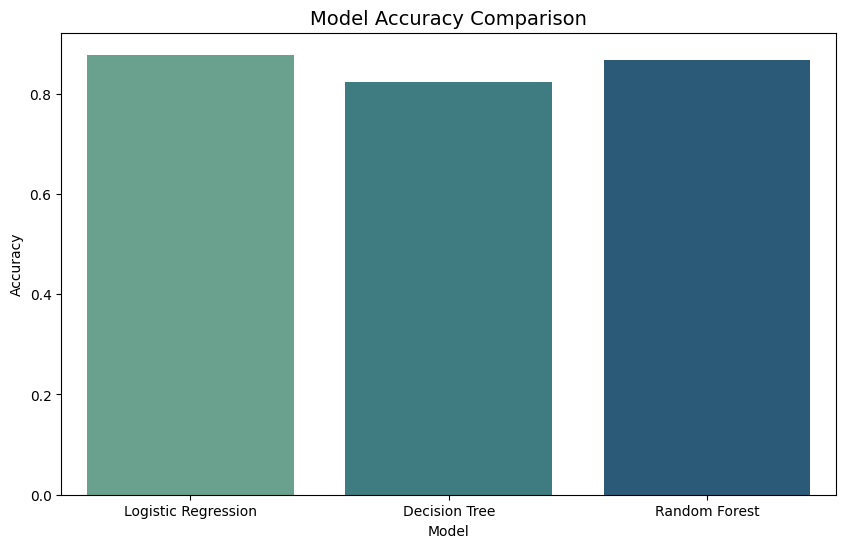

In [10]:
# 5. Visualization

# (a) Bar Plot for Model Accuracy

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="crest")
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()



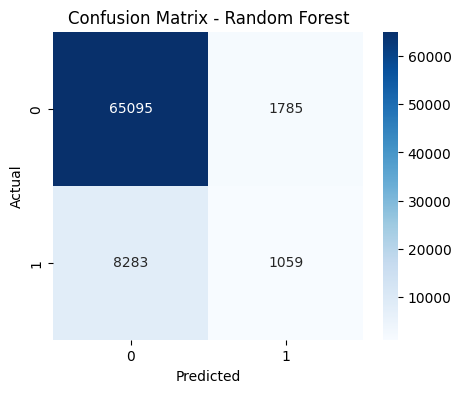

In [12]:
# (b) Confusion Matrix (Random Forest)

best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


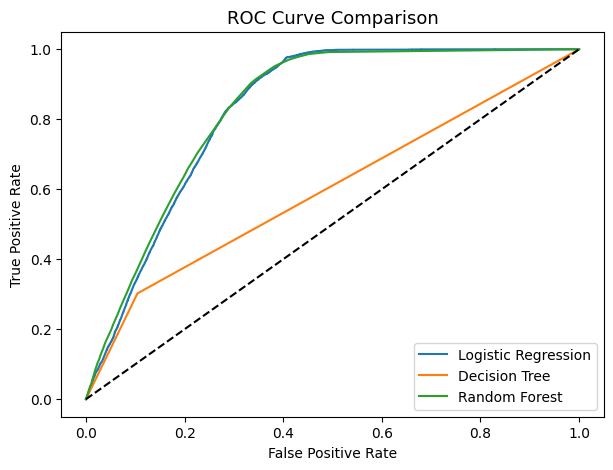

In [13]:
# (c) ROC Curve Comparison

plt.figure(figsize=(7, 5))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name}')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

/tmp/ipython-input-893102225.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_df, palette="magma")


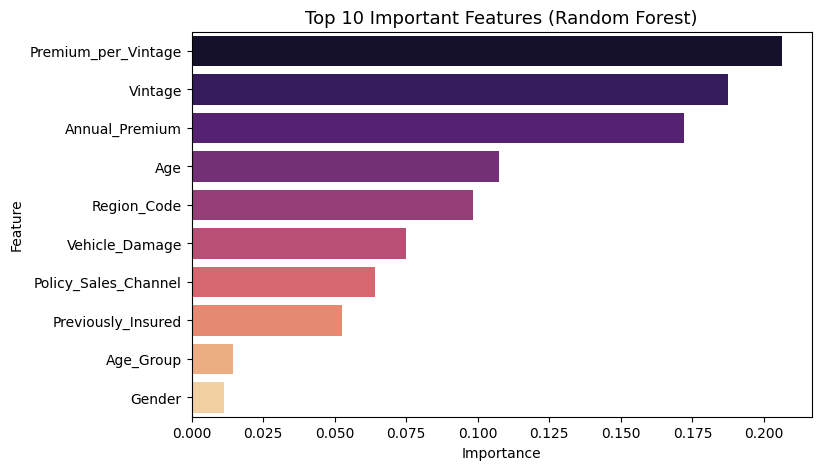

In [14]:
# (d) Feature Importance (Random Forest)

importances = best_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({"Feature": features, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=feat_df, palette="magma")
plt.title("Top 10 Important Features (Random Forest)", fontsize=13)
plt.show()

In [15]:
# 6. Summary


print("\n Final Model Selected: Random Forest Classifier")
print(" Best Overall Accuracy and Stability.")
print("\nTop Important Features:\n", feat_df)


 Final Model Selected: Random Forest Classifier
 Best Overall Accuracy and Stability.

Top Important Features:
                  Feature  Importance
11   Premium_per_Vintage    0.206284
9                Vintage    0.187456
7         Annual_Premium    0.172007
1                    Age    0.107246
3            Region_Code    0.098179
6         Vehicle_Damage    0.074813
8   Policy_Sales_Channel    0.063998
4     Previously_Insured    0.052409
10             Age_Group    0.014417
0                 Gender    0.011499
